# Module 2: Supervised Predictive Modeling
## Bias-Variance Tradeoff, Algorithmic Complexity & Evaluation Metrics

**Objective:** Compare three fundamentally different classification algorithms — **Logistic Regression** (linear, high-bias), **Support Vector Classifier with RBF kernel** (non-linear, flexible), and **Random Forest** (ensemble, high-variance) — on a shared, real-world task derived from the `USA_Housing.csv` dataset.

We will:
1. Engineer a binary classification target from a continuous housing price column.
2. Build divergent preprocessing pipelines that respect each algorithm's mathematical assumptions.
3. Train all three models.
4. Visualize their decision boundaries in 2D to make the bias-variance tradeoff *visible*, not just theoretical.
5. Compare them rigorously using ROC and Precision-Recall curves — not just accuracy.


## 0. Imports & Configuration

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42


## 1. Data Setup & Feature Engineering

`USA_Housing.csv` was built for **regression** — the target `Price` is continuous. To repurpose it for **classification**, we binarize the target using the median as a threshold:

$$
\text{Is\_Premium} =
\begin{cases}
1 & \text{if Price} > \text{median(Price)} \\
0 & \text{otherwise}
\end{cases}
$$

Using the **median** (rather than an arbitrary cutoff) guarantees an almost perfectly balanced 50/50 class split, which matters for two reasons:
- It removes class imbalance as a confounding variable, so any performance differences we see between models are attributable to *model behavior*, not to skewed priors.
- It gives us a meaningful baseline: a random/majority-class classifier scores ~0.50 accuracy, so anything above that reflects real signal.

We also drop:
- `Price` — the source of label leakage (it *is* the label, just not yet binarized).
- `Address` — a high-cardinality free-text field that isn't naturally usable by these models without additional NLP feature extraction, which is out of scope here.

In [11]:
# Load dataset
df = pd.read_csv("USA_Housing.csv")
df.head()


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [12]:
# --- Feature Engineering: regression target -> binary classification target ---
price_median = df["Price"].median()
df["Is_Premium"] = (df["Price"] > price_median).astype(int)

# Drop the raw price (label leakage) and the free-text Address column
df_model = df.drop(columns=["Price", "Address"])

# Separate features (X) and target (y)
X = df_model.drop(columns=["Is_Premium"])
y = df_model["Is_Premium"]

print(f"Median Price threshold: ${price_median:,.2f}")
print("\nClass balance:")
print(y.value_counts(normalize=True).rename("proportion"))


Median Price threshold: $1,232,669.38

Class balance:
Is_Premium
0    0.5
1    0.5
Name: proportion, dtype: float64


In [13]:
# Stratified train/test split preserves the class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
X_train.describe()


Train shape: (4000, 5)
Test shape:  (1000, 5)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,68450.725509,5.983253,6.980402,3.956283,36236.326657
std,10701.556968,0.990306,1.009028,1.236558,9961.992629
min,17796.631190,2.797215,3.236194,2.000000,172.610686
25%,61435.532398,5.334884,6.281527,3.130000,29425.011539
50%,68647.507310,5.959012,6.997041,4.030000,36325.733193
75%,75664.966182,6.651938,7.670842,4.480000,42993.962209
max,107701.748378,9.519088,10.759588,6.500000,69621.713378


## 2. Preprocessing Divergence: Why Scaling Splits Our Pipeline

This is the mathematical heart of the exercise. **Logistic Regression** and **SVM (RBF)** are *distance-* and *gradient-sensitive* algorithms:

- **Logistic Regression** fits coefficients via gradient descent on a log-loss surface. Features on wildly different numeric scales (e.g. `Avg. Area Income` ~ tens of thousands vs `Avg. Area Number of Rooms` ~ single digits) produce an elongated, poorly-conditioned loss surface, which slows/destabilizes convergence and lets large-magnitude features dominate the learned coefficients regardless of their actual predictive value.
- **SVM with an RBF kernel** computes similarity between points using a Euclidean-distance-based kernel:
$$
K(x_i, x_j) = \exp\left(-\gamma \lVert x_i - x_j \rVert^2 \right)
$$
  If one feature's scale dwarfs the others, it will dominate this distance calculation, effectively causing the model to ignore the smaller-scale features entirely.

**Standardizing** each feature to zero mean and unit variance
$$
z = \frac{x - \mu}{\sigma}
$$
puts every feature on equal footing before distance/gradient calculations occur.

**Random Forest**, in contrast, is a **tree-based, split-based** algorithm. At each node it asks "is feature $j$ greater than threshold $t$?" — a question whose answer (and whose resulting information gain / Gini impurity reduction) is **invariant to monotonic transformations** of that feature. Multiplying `Avg. Area Income` by 1000 or standardizing it changes *where* the threshold falls numerically, but not the *rank order* of the data points relative to it — so the tree's splits, and therefore its predictions, are unaffected. Scaling a Random Forest's inputs is mathematically inert; we skip it to keep the pipeline honest about what each algorithm actually needs.

In [14]:
# --- Pipeline A: Scaled features, for distance/gradient-based models (LogReg, SVM) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # fit ONLY on train to avoid data leakage

# --- Pipeline B: Raw (unscaled) features, for the split-based Random Forest ---
X_train_raw = X_train.values
X_test_raw = X_test.values

print("Scaled training feature means (should be ~0):")
print(np.round(X_train_scaled.mean(axis=0), 3))
print("\nScaled training feature std devs (should be ~1):")
print(np.round(X_train_scaled.std(axis=0), 3))


Scaled training feature means (should be ~0):
[-0.  0.  0. -0. -0.]

Scaled training feature std devs (should be ~1):
[1. 1. 1. 1. 1.]


## 3. Model Training

Each model is trained on the preprocessing format appropriate to its assumptions:

| Model | Input | Complexity / Inductive Bias |
|---|---|---|
| Logistic Regression | Scaled | Linear decision boundary — high bias, low variance |
| SVM (RBF kernel) | Scaled | Smooth non-linear boundary — moderate bias/variance, tunable via `C`, `gamma` |
| Random Forest | Raw | Axis-aligned, piecewise decision boundary from an ensemble of trees — low bias, higher variance (mitigated by bagging/averaging) |

In [15]:
# Logistic Regression: linear model, scaled input
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# SVM with RBF kernel: non-linear, distance-based, scaled input
svc_rbf = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
svc_rbf.fit(X_train_scaled, y_train)

# Random Forest: ensemble of decision trees, raw/unscaled input
rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_clf.fit(X_train_raw, y_train)

# Bundle each model with the correct TEST data format for downstream evaluation
models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "SVM (RBF Kernel)":     (svc_rbf, X_test_scaled),
    "Random Forest":        (rf_clf, X_test_raw),
}

print("Held-out test accuracy:")
for name, (model, X_te) in models.items():
    acc = model.score(X_te, y_test)
    print(f"  {name:22s}: {acc:.4f}")


Held-out test accuracy:
  Logistic Regression   : 0.9160
  SVM (RBF Kernel)      : 0.9010
  Random Forest         : 0.8930


## 4. Decision Boundary Visualization

Accuracy alone hides *how* each model is drawing its decision. To make the bias-variance tradeoff visible, we project the problem down to **two features** — `Avg. Area Income` and `Area Population` — and refit lightweight 2D versions of each model purely for plotting.

**What to look for:**
- **Logistic Regression** will produce a single **straight line** dividing the plane. This is the geometric signature of high bias: no matter how the true boundary curves, this model can only ever offer a linear approximation of it.
- **SVM (RBF)** will produce a **smooth, curved** boundary that can wrap around clusters of points — lower bias than the linear model, but more sensitive to the specific training sample (higher variance) since the kernel bandwidth (`gamma`) controls how tightly it can flex.
- **Random Forest** will produce a **blocky, axis-aligned, jagged** boundary — the union of many rectangular splits. This is the visual fingerprint of a low-bias, high-variance model: it can fit almost any shape in the training data, including noise, which is why ensembling (averaging many trees) is essential to keep it from overfitting.

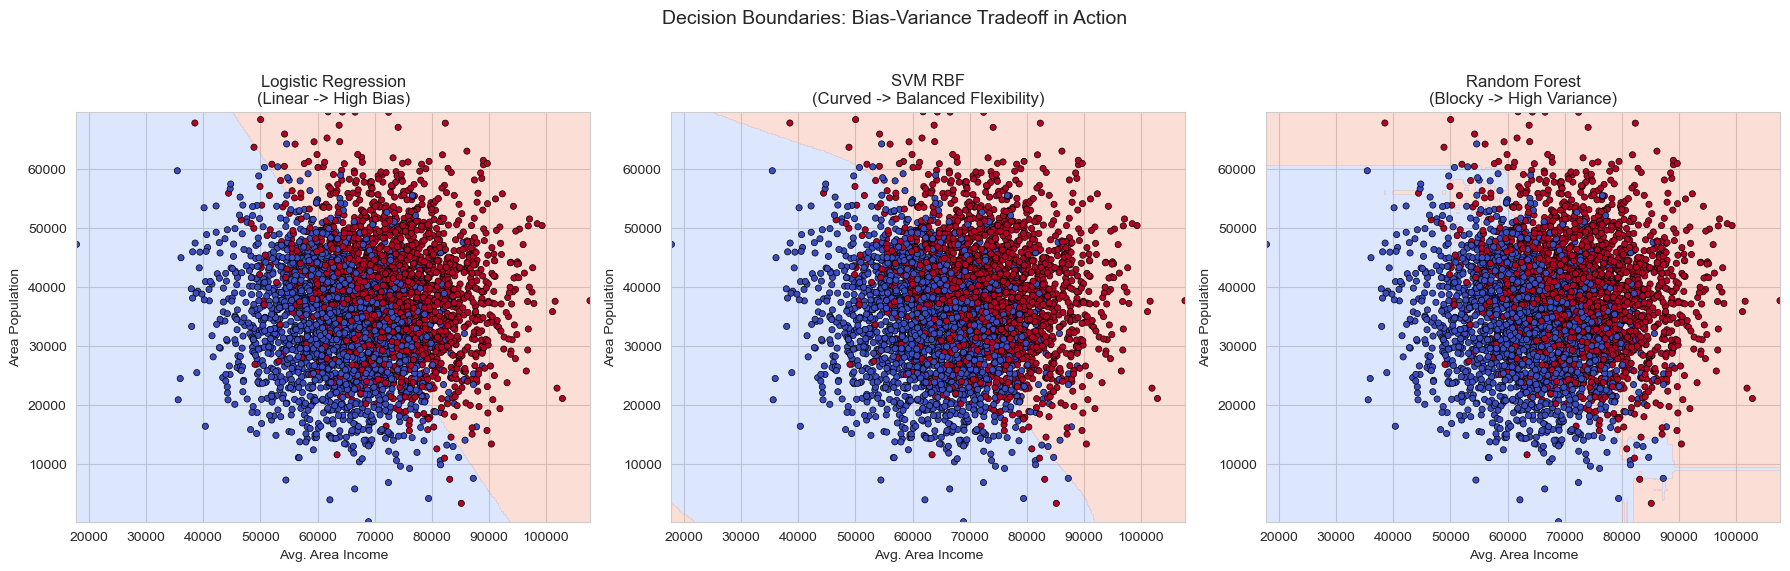

In [16]:
def plot_decision_boundaries(X_2d, y_2d, feature_names):
    """
    Fits lightweight 2-feature versions of Logistic Regression, SVM (RBF),
    and Random Forest purely for the purpose of visualizing decision boundary
    SHAPE (linear vs. curved vs. blocky). These 2D models are NOT the same
    fitted objects used for the metric evaluation in Section 5 -- they exist
    only so the bias-variance tradeoff can be seen on a 2D plane.
    """
    # Distance-based models still need scaling, even in this 2D toy view.
    # Fit the scaler on the underlying numpy array (not the DataFrame) so
    # its feature-name bookkeeping doesn't mismatch the plain ndarray mesh
    # grid used later -- avoids a spurious sklearn UserWarning at plot time.
    X_2d_values = X_2d.values
    scaler_2d = StandardScaler()
    X_2d_scaled = scaler_2d.fit_transform(X_2d_values)

    lr_2d = LogisticRegression(random_state=RANDOM_STATE).fit(X_2d_scaled, y_2d)
    svc_2d = SVC(kernel="rbf", random_state=RANDOM_STATE).fit(X_2d_scaled, y_2d)
    rf_2d = RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE
    ).fit(X_2d_values, y_2d)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    titles = [
        "Logistic Regression\n(Linear -> High Bias)",
        "SVM RBF\n(Curved -> Balanced Flexibility)",
        "Random Forest\n(Blocky -> High Variance)",
    ]
    fitted = [
        (lr_2d, scaler_2d),
        (svc_2d, scaler_2d),
        (rf_2d, None),   # Random Forest uses raw (unscaled) coordinates
    ]

    x_min, x_max = X_2d.iloc[:, 0].min() - 1, X_2d.iloc[:, 0].max() + 1
    y_min, y_max = X_2d.iloc[:, 1].min() - 1, X_2d.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300)
    )
    grid_raw = np.c_[xx.ravel(), yy.ravel()]

    for ax, title, (model, scaler_obj) in zip(axes, titles, fitted):
        grid = scaler_obj.transform(grid_raw) if scaler_obj is not None else grid_raw
        Z = model.predict(grid).reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm", levels=1)
        ax.scatter(
            X_2d.iloc[:, 0], X_2d.iloc[:, 1],
            c=y_2d, cmap="coolwarm", edgecolor="k", s=20, linewidths=0.5
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])

    plt.suptitle("Decision Boundaries: Bias-Variance Tradeoff in Action", y=1.03, fontsize=14)
    plt.tight_layout()
    plt.show()


viz_features = ["Avg. Area Income", "Area Population"]
plot_decision_boundaries(X_train[viz_features], y_train, viz_features)


## 5. Metric Evaluation Showdown: ROC and Precision-Recall

A single accuracy number can mask important differences in *how* a model makes mistakes, and it's misleading whenever class balance shifts or the cost of false positives/negatives is asymmetric. We compare all three models on the same axes using two complementary curves:

- **ROC curve** (True Positive Rate vs. False Positive Rate, area = AUC): summarizes how well a model ranks positive cases above negative cases across *all* classification thresholds, independent of any single cutoff. An AUC of 0.5 is random guessing; 1.0 is perfect ranking.
- **Precision-Recall curve** (Precision vs. Recall, area = Average Precision): more informative than ROC when you care specifically about the positive class and its false-positive cost — a distinction ROC's use of the (typically large) negative class can obscure. Because our classes are balanced here (median split), ROC and PR should broadly agree, which is itself a useful sanity check.

Plotting all three models on shared axes lets you directly compare not just final scores but the *shape* of the tradeoff curve each model offers at different thresholds.

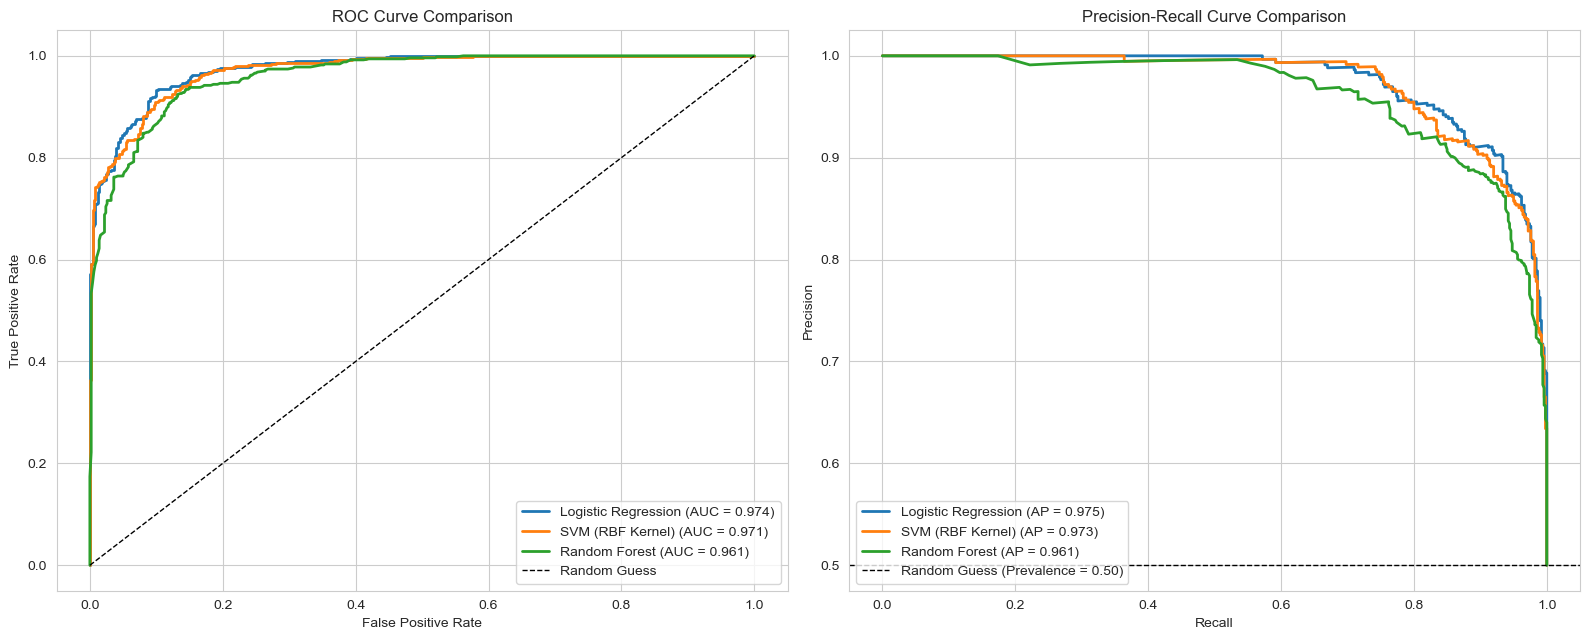

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

for name, (model, X_te) in models.items():
    y_scores = model.predict_proba(X_te)[:, 1]

    # --- ROC ---
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

    # --- Precision-Recall ---
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    ap = average_precision_score(y_test, y_scores)
    axes[1].plot(recall, precision, linewidth=2, label=f"{name} (AP = {ap:.3f})")

# ROC formatting
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve Comparison")
axes[0].legend(loc="lower right")

# PR formatting
baseline = y_test.mean()
axes[1].axhline(baseline, color="k", linestyle="--", linewidth=1,
                 label=f"Random Guess (Prevalence = {baseline:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve Comparison")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


### Interpreting the Results

- If **Random Forest** posts the highest AUC/AP but its 2D decision boundary in Section 4 looked visibly jagged around individual points, that jaggedness is the *cost* of its flexibility — it's a warning sign to check for overfitting via cross-validation or a learning curve, not just trust the single train/test split.
- If **Logistic Regression** performs competitively despite its rigid linear boundary, that's evidence the true decision surface for `Is_Premium` is close to linear in feature space — a case where the added complexity of SVM/RF buys little and a simpler, more interpretable, cheaper-to-serve model may be the better production choice.
- Large gaps between a model's **train accuracy** (not shown above — add `model.score(X_train_*, y_train)` if you want to check) and its **test accuracy** are the classic numerical signature of high variance/overfitting, complementing what the decision boundary plot shows visually.

In [18]:
# Optional: quick train-vs-test accuracy check to numerically confirm
# any overfitting suggested by the decision boundary shapes above
train_data = {
    "Logistic Regression": X_train_scaled,
    "SVM (RBF Kernel)": X_train_scaled,
    "Random Forest": X_train_raw,
}

print(f"{'Model':22s} {'Train Acc':>10s} {'Test Acc':>10s} {'Gap':>8s}")
for name, (model, X_te) in models.items():
    train_acc = model.score(train_data[name], y_train)
    test_acc = model.score(X_te, y_test)
    print(f"{name:22s} {train_acc:10.4f} {test_acc:10.4f} {train_acc - test_acc:8.4f}")


Model                   Train Acc   Test Acc      Gap
Logistic Regression        0.9090     0.9160  -0.0070
SVM (RBF Kernel)           0.9130     0.9010   0.0120
Random Forest              1.0000     0.8930   0.1070
